In [1]:
import cv2
import matplotlib.pyplot as plt
import time

In [2]:
import cv2
import numpy as np

video_path = "/workspace/test_videos/cam2_1754411798.mp4"
cap = cv2.VideoCapture(video_path)

frames = []

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Optional: resize to consistent dimensions
    # frame = cv2.resize(frame, (224, 224))

    # Convert BGR → RGB
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Convert to float32 and normalize [0,1]
    frame = frame.astype(np.float32) / 255.0

    frames.append(frame)

cap.release()

# Stack into a 4D NumPy tensor
video_tensor = np.stack(frames)  # shape: (num_frames, H, W, 3)

print("Video tensor shape:", video_tensor.shape)

masked_video_path = "/workspace/test_results/cam2_1754411798.avi"
cap = cv2.VideoCapture(video_path)

frames = []

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Optional: resize to consistent dimensions
    # frame = cv2.resize(frame, (224, 224))

    # Convert BGR → RGB
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Convert to float32 and normalize [0,1]
    frame = frame.astype(np.float32) / 255.0

    frames.append(frame)

cap.release()

# Stack into a 4D NumPy tensor
masked_video_tensor = np.stack(frames)  # shape: (num_frames, H, W, 3)

print("Video tensor shape:", video_tensor.shape)



Video tensor shape: (300, 480, 640, 3)
Video tensor shape: (300, 480, 640, 3)


In [3]:
path = "/workspace/test_results/cam2_1754411798.npy"
segmened_video = np.load(path)

In [4]:
import cv2
import numpy as np

def to_gray_u8(img):
    # If 3/4-channel -> convert to gray
    if img.ndim == 3:
        if img.shape[2] == 3:
            g = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        elif img.shape[2] == 4:
            g = cv2.cvtColor(img, cv2.COLOR_BGRA2GRAY)
        else:
            raise ValueError(f"Unexpected channel count: {img.shape[2]}")
    else:
        g = img

    # Ensure uint8 range
    if g.dtype != np.uint8:
        g = np.clip(g, 0, 255)
        if g.max() <= 1.0:  # looks like 0..1 float
            g = (g * 255.0).astype(np.uint8)
        else:
            g = g.astype(np.uint8)
    return g

def estimate_rotation_R(prev_img, curr_img, K):
    prev_gray = to_gray_u8(prev_img)
    gray = to_gray_u8(curr_img)

    mask = np.zeros(gray.shape, np.uint8)
    mask[int(0.2*h):int(0.8*h), int(0.2*w):int(0.8*w)] = 255

    
    orb = cv2.ORB_create(nfeatures=2000)
    kp1, des1 = orb.detectAndCompute(prev_gray, mask)
    kp2, des2 = orb.detectAndCompute(gray, mask)
    
    if des1 is None or des2 is None or len(kp1) < 8 or len(kp2) < 8:
        raise RuntimeError("Not enough ORB features/descriptors.")

    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)
    if len(matches) < 8:
        raise RuntimeError("Not enough matches after ORB.")

    matches = sorted(matches, key=lambda m: m.distance)[:800]
    pts1 = np.float32([kp1[m.queryIdx].pt for m in matches])  # prev
    pts2 = np.float32([kp2[m.trainIdx].pt for m in matches])  # curr

    F, maskF = cv2.findFundamentalMat(pts1, pts2, cv2.FM_RANSAC, 0.7, 0.99)
    if F is None:
        raise RuntimeError("findFundamentalMat failed.")
    pts1 = pts1[maskF.ravel() == 1]
    pts2 = pts2[maskF.ravel() == 1]
    if len(pts1) < 8:
        raise RuntimeError("Too few inliers after F RANSAC.")

    E, maskE = cv2.findEssentialMat(pts2, pts1, K, method=cv2.RANSAC, prob=0.999, threshold=1.0)
    if E is None:
        raise RuntimeError("findEssentialMat failed.")
    _, R, t, maskPose = cv2.recoverPose(E, pts2, pts1, K)
    return R  # 3x3 rotation from prev -> curr

In [5]:
gray_tensor = np.stack([
    cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    for frame in video_tensor
])

In [8]:
gray_frame = cv2.cvtColor(video_tensor[200], cv2.COLOR_RGB2GRAY)
gray_frame_last = cv2.cvtColor(video_tensor[196], cv2.COLOR_RGB2GRAY)

w = 640
width = w
h = 480
height = h
fov_deg = 120
fov_rad = np.deg2rad(fov_deg)

fx = width / (2 * np.tan(fov_rad / 2))  # ~185.37 px
fy = fx  # Assuming square pixels and similar vertical FOV

cx = width / 2   # 320
cy = height / 2  # 240

K = np.array([
    [fx,  0, cx],
    [ 0, fy, cy],
    [ 0,  0,  1]
])


import numpy as np

def r2ypr_zyx(R):
    # clamp to avoid NaNs from tiny numerical errors
    sy = -R[2,0]
    sy = np.clip(sy, -1.0, 1.0)
    pitch = np.arcsin(sy)
    roll  = np.arctan2(R[2,1], R[2,2])
    yaw   = np.arctan2(R[1,0], R[0,0])
    return yaw, pitch, roll  # in radians



R = estimate_rotation_R(gray_frame_last, gray_frame, K)

r2ypr_zyx(R)

(-0.03617051144822145, -0.017990014316906312, -0.034677861637435387)

In [9]:
def r2q(R):
    # (w, x, y, z)
    K = np.array([
        [R[0,0]-R[1,1]-R[2,2], 0, 0, 0],
        [R[1,0]+R[0,1], R[1,1]-R[0,0]-R[2,2], 0, 0],
        [R[2,0]+R[0,2], R[2,1]+R[1,2], R[2,2]-R[0,0]-R[1,1], 0],
        [R[1,2]-R[2,1], R[2,0]-R[0,2], R[0,1]-R[1,0], R[0,0]+R[1,1]+R[2,2]]
    ]) / 3.0
    w, V = np.linalg.eigh(K)
    q = V[:, np.argmax(w)]
    q = np.array([q[3], q[0], q[1], q[2]])  # to (w,x,y,z)
    return q/np.linalg.norm(q)

def q_slerp(q0, q1, alpha):
    # alpha in [0,1]
    dot = np.dot(q0, q1)
    if dot < 0: q1, dot = -q1, -dot
    if dot > 0.9995:
        q = q0 + alpha*(q1-q0)
        return q/np.linalg.norm(q)
    theta = np.arccos(np.clip(dot, -1, 1))
    s0 = np.sin((1-alpha)*theta)/np.sin(theta)
    s1 = np.sin(alpha*theta)/np.sin(theta)
    return s0*q0 + s1*q1

    
alpha = 0  # smoothing (increase for more smoothing)
q_global = np.array([1,0,0,0])
q_global_tensor = np.zeros((4, 299))

time0 = time.time()

for i in range(299):
    gray_frame = gray_tensor[i +1]
    gray_frame_last = gray_tensor[i]
    R_step = estimate_rotation_R(gray_frame_last, gray_frame, K)
    q_step = r2q(R_step)
    q_global = q_slerp(q_global, q_step*q_global, alpha)  # compose then smooth
    q_global_tensor[:, i] = q_global
print(f"total time = {time.time() - time0}")

total time = 14.713578224182129


In [10]:
q_global_tensor

array([[1., 1., 1., ..., 1., 1., 1.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

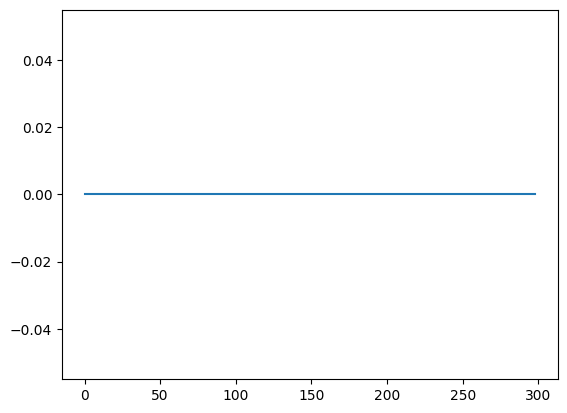

In [11]:
plt.plot(q_global_tensor[2])

In [13]:
import numpy as np, time

def r2ypr_zyx(R):
    """
    Extract yaw (Z), pitch (Y), roll (X) from rotation matrix using ZYX order.
    Returns radians: (yaw, pitch, roll).
    """
    # clamp to handle tiny numeric errors
    sy = -R[2,0]
    sy = np.clip(sy, -1.0, 1.0)
    pitch = np.arcsin(sy)
    roll  = np.arctan2(R[2,1], R[2,2])
    yaw   = np.arctan2(R[1,0], R[0,0])
    return yaw, pitch, roll

# ---- no smoothing, just Euler updates ----
N = gray_tensor.shape[0] - 1  # because we use i and i+1
R_global = np.eye(3)

ypr_global = np.zeros((3, N))      # radians: rows = [yaw, pitch, roll]
ypr_step   = np.zeros((3, N))      # optional: per-frame incremental angles

t0 = time.time()
for i in range(N):
    gray_frame_last = gray_tensor[i]
    gray_frame      = gray_tensor[i+1]

    # relative rotation from frame i -> i+1
    R_step = estimate_rotation_R(gray_frame_last, gray_frame, K)

    # (optional) per-step angles (incremental)
    ypr_step[:, i] = r2ypr_zyx(R_step)

    # compose to keep a running/global orientation
    R_global = R_step @ R_global

    # global angles after this update
    ypr_global[:, i] = r2ypr_zyx(R_global)

print(f"total time = {time.time() - t0:.3f}s")

# If you want degrees:
ypr_global_deg = np.degrees(ypr_global)
ypr_step_deg   = np.degrees(ypr_step)


total time = 16.278s


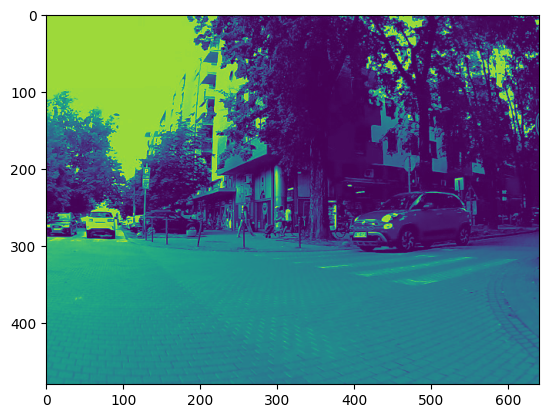

In [14]:
plt.imshow(gray_tensor[299])

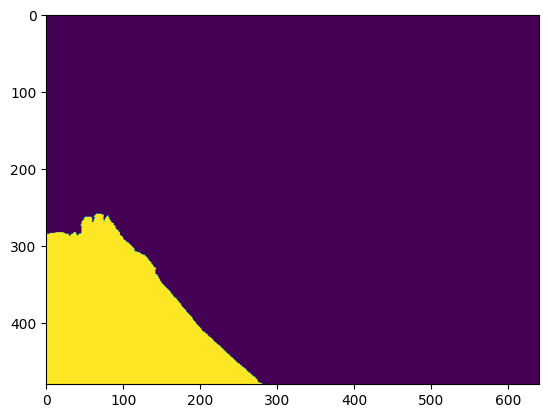

In [41]:
mask = np.equal(segmened_video[100], 0)
plt.imshow(mask)

In [ ]:
    @staticmethod
    def _rot_from_rpy(roll: float, pitch: float, yaw: float) -> np.ndarray:
        # Base alignment: world (X right, Y fwd, Z up) -> camera (x right, y down, z fwd)
        R_align = np.array([
            [1, 0,  0],   # Xw -> xc
            [0, 0, -1],   # Zw -> -yc
            [0, 1,  0],   # Yw ->  zc
        ], dtype=np.float64)

        cz, sz = np.cos(yaw),   np.sin(yaw)
        cy, sy = np.cos(pitch), np.sin(pitch)
        cx, sx = np.cos(roll),  np.sin(roll)

        Rz = np.array([[ cz, -sz, 0],
                       [ sz,  cz, 0],
                       [  0,   0, 1]], dtype=np.float64)
        Ry = np.array([[ cy, 0, sy],
                       [  0, 1,  0],
                       [-sy, 0, cy]], dtype=np.float64)
        Rx = np.array([[1,  0,   0],
                       [0, cx, -sx],
                       [0, sx,  cx]], dtype=np.float64)

        # World -> camera: first apply yaw/pitch/roll in WORLD, then align frames
        # (ZYX on world; positive pitch tilts camera down toward the road.)
        R_world = Rx @ Ry @ Rz
        return R_align @ R_world

In [32]:
fx = fy = 1100.0
proj = BEVProjector()
cx0, cy0 = W/2.0, H/2.0
K = np.array([[fx, 0,   cx0],
              [0,  fy,  cy0],
              [0,  0,   1.0]], dtype=np.float64)

# Set intrinsics + pose (height + pitch)
proj_cal = proj.set_intrinsics(K).set_pose(
    height_m=1.4,
    roll=0.0,
    pitch=-np.deg2rad(6.0),
    yaw=0.0
)

grid = BEVGrid(
    meters_per_pixel=0.10,          # 10 cm/pixel
    forward_range_m=(0.0, 25.0),    # 0–25 m ahead
    lateral_range_m=(-6.0, 6.0)     # ±6 m left/right
)

bev_cal = proj_cal.warp_calibrated(mask01=mask, grid=grid)


In [33]:
proj.M

array([[ 1.31136457e-02,  0.00000000e+00, -4.78716322e+01],
       [ 1.69689064e-02, -9.09090909e-03, -1.83283725e+02],
       [ 6.78756255e-05,  0.00000000e+00, -7.42953083e-01]])

In [34]:
bev_cal.sum()

0

In [35]:
mask.sum()

151873

In [14]:
proj_calib

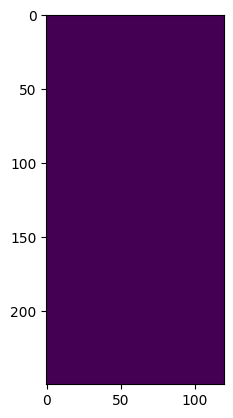

In [15]:
plt.imshow(bev_cal)

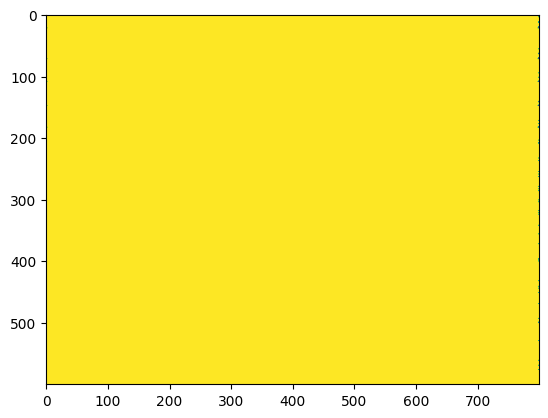

In [61]:
plt.imshow(bev_trap)

In [55]:
mask01 = mask

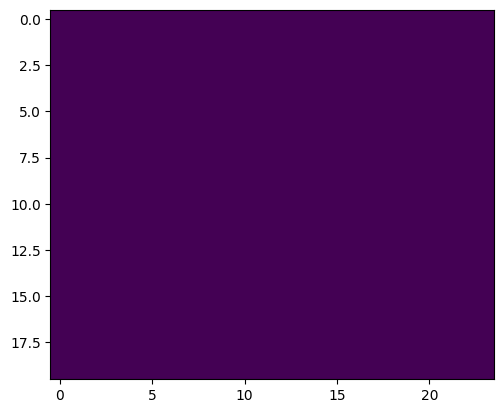

In [59]:
plt.imshow(bev)

In [39]:
np.bincount(segmened_video[299].ravel())

array([116071,   6692,  33745,      0,   2491,   1562,      0,    894,
       104428,    257,  25401,   1613,      0,  13388,      0,      0,
            0,     17,    641])

In [40]:
gray_tensor.shape

(300, 480, 640)

In [129]:
video_tensor[250][400:, :100].shape

(80, 100, 3)

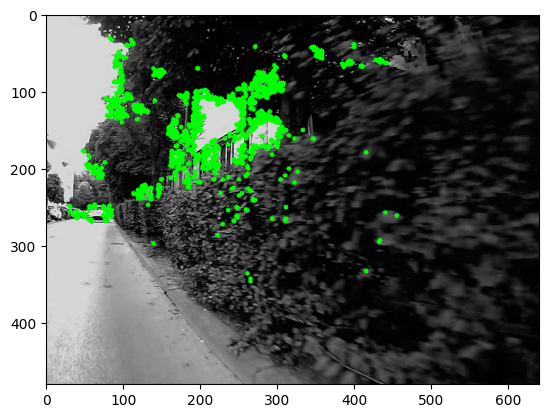

In [211]:
import cv2, numpy as np

def to_gray_u8(img):
    if img.ndim == 3: img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    if img.dtype != np.uint8:
        img = (np.clip(img,0,1)*255).astype(np.uint8) if img.max()<=1.0 else np.clip(img,0,255).astype(np.uint8)
    return img

def to_bgr_u8(img):
    if img.ndim == 2: img = cv2.cvtColor(to_gray_u8(img), cv2.COLOR_GRAY2BGR)
    if img.dtype != np.uint8:
        img = (np.clip(img,0,1)*255).astype(np.uint8) if img.max()<=1.0 else np.clip(img,0,255).astype(np.uint8)
    return img

def draw_orb_points(img, nfeatures=1500, mask=None, max_draw=None):
    """Detect ORB features and draw them as points (no matches)."""
    g = to_gray_u8(img)
    orb = cv2.ORB_create(nfeatures=nfeatures)
    kps = orb.detect(g, mask)
    if not kps: 
        return to_bgr_u8(img)
    # optionally keep top-N by response
    if max_draw is not None and len(kps) > max_draw:
        kps = sorted(kps, key=lambda k:k.response, reverse=True)[:max_draw]
    vis = to_bgr_u8(img).copy()
    for kp in kps:
        x,y = map(int, kp.pt)
        cv2.circle(vis, (x,y), 3, (0,255,0), -1)
    return vis

n = 52


gray_frame_last = gray_tensor[n]


# g: HxW uint8 grayscale (what ORB expects)
g = to_gray_u8(gray_frame_last)  # ensures single channel uint8
h, w = g.shape

# Build a proper mask from your segmented labels
m = (segmened_video[n] != 13)    # boolean mask (True = keep)
if m.ndim == 3:
    # If segmentation is HxWxC, collapse channels (keep any non-13 across channels)
    m = np.any(m, axis=-1)

# Cast to uint8 0/255
m = m.astype(np.uint8) * 255

# Zero out the top 300 rows (cap to image height to be safe)
m[:min(300, h), :] = 0

# Ensure mask size matches the image; if not, resize with NEAREST (keeps 0/255)
if m.shape != (h, w):
    m = cv2.resize(m, (w, h), interpolation=cv2.INTER_NEAREST)

# Make sure it’s contiguous and single-channel
m = np.ascontiguousarray(m)

# Now detect
vis = draw_orb_points(g, max_draw=1500)  # g is fine (uint8), m is uint8 0/255

plt.imshow(vis)





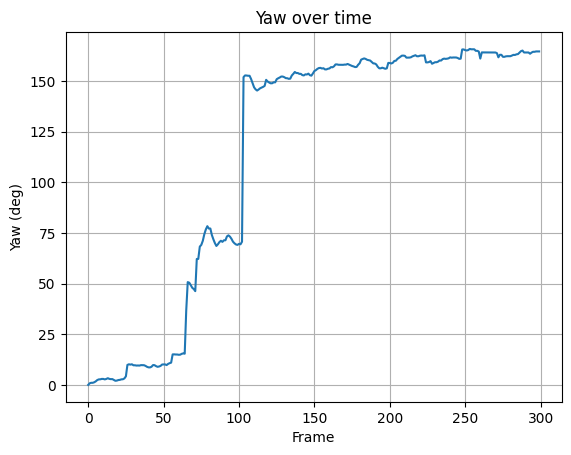

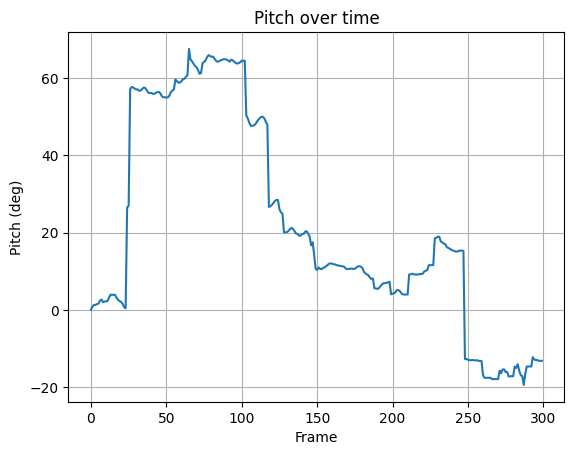

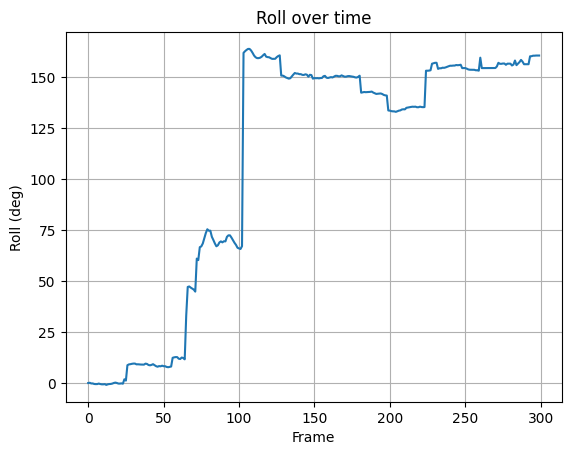

Frames processed: 300; accepted (inliers >= 60): 106


In [213]:
# --- Robust camera orientation tracker + plots (single cell) ---
import cv2, numpy as np
from math import atan2, asin, tan, radians, degrees
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# Utilities
# ---------------------------------------------------------------
def to_gray_u8(img):
    """Return a single-channel uint8 grayscale image."""
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    if img.dtype != np.uint8:
        mx = float(img.max()) if img.size else 1.0
        if mx <= 1.0:
            img = (np.clip(img, 0, 1) * 255).astype(np.uint8)
        else:
            img = np.clip(img, 0, 255).astype(np.uint8)
    return img

def build_mask(seg_frame, h, w, ignore_label=13, top_cut=300):
    """
    Make a uint8 (0/255) mask where 255 means 'use for features'.
    - Ignores pixels with label == ignore_label
    - Zeros out top 'top_cut' rows
    """
    # Accept HxW or HxWxC segmentation; keep any non-ignore label across channels
    m = (seg_frame != ignore_label)
    if m.ndim == 3:
        m = np.any(m, axis=-1)
    m = m.astype(np.uint8) * 255

    if m.shape != (h, w):
        if m.size == 0:
            m = np.zeros((h, w), np.uint8)
        else:
            m = cv2.resize(m, (w, h), interpolation=cv2.INTER_NEAREST)

    m[:min(top_cut, h), :] = 0  # zero out the top band
    return np.ascontiguousarray(m)

def euler_zyx_from_R(R):
    """
    Convert rotation matrix to ZYX (yaw, pitch, roll), radians.
    R = Rz(yaw) * Ry(pitch) * Rx(roll)
    """
    sy = -R[2, 0]
    sy = float(np.clip(sy, -1.0, 1.0))  # guard for numeric drift
    pitch = asin(sy)
    roll  = atan2(R[2, 1], R[2, 2])
    yaw   = atan2(R[1, 0], R[0, 0])
    return yaw, pitch, roll

def intrinsics_from_fov(h, w, fov_deg=60.0):
    """Simple pinhole intrinsics assuming centered principal point and square pixels."""
    f = 0.5 * w / tan(radians(fov_deg * 0.5))
    K = np.array([[f, 0, w/2.0],
                  [0, f, h/2.0],
                  [0, 0, 1.0]], dtype=np.float64)
    return K

    
# 1) Replace preprocess_frame with this version
def preprocess_frame(img):
    """Grayscale uint8 -> light denoise -> CLAHE -> mild sharpen."""
    g = to_gray_u8(img)  # <-- ensure single-channel uint8 first
    g = cv2.GaussianBlur(g, (3, 3), sigmaX=0.8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    g = clahe.apply(g)
    sharp = cv2.GaussianBlur(g, (0, 0), sigmaX=1.0)
    g = cv2.addWeighted(g, 1.5, sharp, -0.5, 0)
    return g


# ---------------------------------------------------------------
# Core tracker (keeps only most reliable matches)
# ---------------------------------------------------------------
def track_orientation(
    gray_tensor, segmened_video,
    ignore_label=13, top_cut=300,
    nfeatures=2500, ratio_thresh=0.75,
    keep_best_N=100,                   # <-- keep only top-N matches by distance
    min_inliers=30,                    # <-- require at least this many inliers to accept a step
    ransac_thresh=1.0, ransac_prob=0.999,
    K=None, fov_deg=60.0,
    smooth_alpha=None                  # e.g., 0.2 for light EMA smoothing of angles
):
    """
    Compute cumulative camera orientation (yaw/pitch/roll in degrees) per frame
    using ORB + robust matching + Essential matrix + recoverPose.

    Returns: list of dict (frame, yaw_deg, pitch_deg, roll_deg, inliers, matches_used)
    """
    N = len(gray_tensor)
    if N < 2:
        return [{"frame": 0, "yaw_deg": 0.0, "pitch_deg": 0.0, "roll_deg": 0.0,
                 "inliers": 0, "matches_used": 0}]

    # ORB + matcher
    orb = cv2.ORB_create(nfeatures=nfeatures)
    bf  = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)

    # Frame 0 preprocess
    g0 = preprocess_frame(gray_tensor[0])   # (instead of mixing manual grayscale + preprocess)
    h, w = g0.shape    
    if K is None:
        K = intrinsics_from_fov(h, w, fov_deg=fov_deg)

    m0 = build_mask(segmened_video[0], h, w, ignore_label, top_cut)
    kp0, des0 = orb.detectAndCompute(g0, mask=m0)

    R_cum = np.eye(3, dtype=np.float64)  # accumulate rotation
    out = [{
        "frame": 0, "yaw_deg": 0.0, "pitch_deg": 0.0, "roll_deg": 0.0,
        "inliers": 0, "matches_used": 0
    }]

    # optional EMA init
    if smooth_alpha is not None:
        yaw_s, pitch_s, roll_s = 0.0, 0.0, 0.0

    for i in range(1, N):
        g1 = preprocess_frame(gray_tensor[i])     # preprocess here too
        if g1.shape != (h, w):
            g1 = cv2.resize(g1, (w, h), interpolation=cv2.INTER_AREA)
    
        m1 = build_mask(segmened_video[i], h, w, ignore_label, top_cut)
        kp1, des1 = orb.detectAndCompute(g1, mask=m1)
        
        # if insufficient features, carry forward orientation
        if des0 is None or des1 is None or len(kp0) < 8 or len(kp1) < 8:
            yaw, pitch, roll = euler_zyx_from_R(R_cum)
            yd, pd, rd = map(degrees, (yaw, pitch, roll))
            if smooth_alpha is not None:
                yaw_s   = (1 - smooth_alpha) * yaw_s   + smooth_alpha * yd
                pitch_s = (1 - smooth_alpha) * pitch_s + smooth_alpha * pd
                roll_s  = (1 - smooth_alpha) * roll_s  + smooth_alpha * rd
                yd, pd, rd = yaw_s, pitch_s, roll_s

            out.append({"frame": i, "yaw_deg": yd, "pitch_deg": pd, "roll_deg": rd,
                        "inliers": 0, "matches_used": 0})
            kp0, des0 = kp1, des1
            continue

        # KNN match + Lowe ratio
        knn = bf.knnMatch(des0, des1, k=2)
        good = []
        for pair in knn:
            if len(pair) == 2:
                a, b = pair
                if a.distance < ratio_thresh * b.distance:
                    good.append(a)

        # Keep only top-N most reliable matches by descriptor distance
        if len(good) > 0:
            good = sorted(good, key=lambda m: m.distance)[:keep_best_N]

        if len(good) < 8:
            yaw, pitch, roll = euler_zyx_from_R(R_cum)
            yd, pd, rd = map(degrees, (yaw, pitch, roll))
            if smooth_alpha is not None:
                yaw_s   = (1 - smooth_alpha) * yaw_s   + smooth_alpha * yd
                pitch_s = (1 - smooth_alpha) * pitch_s + smooth_alpha * pd
                roll_s  = (1 - smooth_alpha) * roll_s  + smooth_alpha * rd
                yd, pd, rd = yaw_s, pitch_s, roll_s

            out.append({"frame": i, "yaw_deg": yd, "pitch_deg": pd, "roll_deg": rd,
                        "inliers": 0, "matches_used": len(good)})
            kp0, des0 = kp1, des1
            continue

        pts0 = np.float32([kp0[m.queryIdx].pt for m in good])
        pts1 = np.float32([kp1[m.trainIdx].pt for m in good])

        # Essential matrix with RANSAC
        E, inliers_E = cv2.findEssentialMat(
            pts0, pts1, K,
            method=cv2.RANSAC, prob=ransac_prob, threshold=ransac_thresh
        )

        if E is None or inliers_E is None or int(np.sum(inliers_E)) < min_inliers:
            # Not reliable enough → keep previous orientation
            yaw, pitch, roll = euler_zyx_from_R(R_cum)
            yd, pd, rd = map(degrees, (yaw, pitch, roll))
            if smooth_alpha is not None:
                yaw_s   = (1 - smooth_alpha) * yaw_s   + smooth_alpha * yd
                pitch_s = (1 - smooth_alpha) * pitch_s + smooth_alpha * pd
                roll_s  = (1 - smooth_alpha) * roll_s  + smooth_alpha * rd
                yd, pd, rd = yaw_s, pitch_s, roll_s

            out.append({"frame": i, "yaw_deg": yd, "pitch_deg": pd, "roll_deg": rd,
                        "inliers": int(np.sum(inliers_E)) if inliers_E is not None else 0,
                        "matches_used": len(good)})
            kp0, des0 = kp1, des1
            continue

        # Recover pose using only inliers_E
        inliers_count, R_step, t, inliers_pose = cv2.recoverPose(
            E, pts0, pts1, K, mask=inliers_E
        )

        # Enforce reliability again
        used_inliers = int(inliers_count) if isinstance(inliers_count, (int, np.integer)) else int(np.sum(inliers_pose))
        if used_inliers < min_inliers:
            yaw, pitch, roll = euler_zyx_from_R(R_cum)
            yd, pd, rd = map(degrees, (yaw, pitch, roll))
            if smooth_alpha is not None:
                yaw_s   = (1 - smooth_alpha) * yaw_s   + smooth_alpha * yd
                pitch_s = (1 - smooth_alpha) * pitch_s + smooth_alpha * pd
                roll_s  = (1 - smooth_alpha) * roll_s  + smooth_alpha * rd
                yd, pd, rd = yaw_s, pitch_s, roll_s

            out.append({"frame": i, "yaw_deg": yd, "pitch_deg": pd, "roll_deg": rd,
                        "inliers": used_inliers, "matches_used": len(good)})
            kp0, des0 = kp1, des1
            continue

        # Accumulate rotation
        R_cum = R_step @ R_cum
        yaw, pitch, roll = euler_zyx_from_R(R_cum)
        yd, pd, rd = map(degrees, (yaw, pitch, roll))

        if smooth_alpha is not None:
            yaw_s   = (1 - smooth_alpha) * yaw_s   + smooth_alpha * yd
            pitch_s = (1 - smooth_alpha) * pitch_s + smooth_alpha * pd
            roll_s  = (1 - smooth_alpha) * roll_s  + smooth_alpha * rd
            yd, pd, rd = yaw_s, pitch_s, roll_s

        out.append({"frame": i, "yaw_deg": yd, "pitch_deg": pd, "roll_deg": rd,
                    "inliers": used_inliers, "matches_used": len(good)})

        # advance
        kp0, des0 = kp1, des1

    return out

# ---------------------------------------------------------------
# Run on your tensors and plot each axis
# ---------------------------------------------------------------
# Expect you already have: gray_tensor, segmened_video
# Example call (tweak params as needed):
orientations = track_orientation(
    gray_tensor, segmened_video,
    ignore_label=200, top_cut=0,
    nfeatures=2500,
    ratio_thresh=0.75,
    keep_best_N=100,
    min_inliers=30,
    ransac_thresh=1.0, ransac_prob=0.999,
    K=None,          # or pass your real camera matrix here
    fov_deg=60.0,
    smooth_alpha=None  # e.g., 0.2 for light smoothing
)

df = pd.DataFrame(orientations)

# Optionally keep only frames with reliable inliers for plotting
df_plot = df[df["inliers"] >= 0].copy()
if df_plot.empty:
    df_plot = df.copy()

# --- Plot each axis (separate figures) ---
plt.figure()
plt.plot(df_plot["frame"], df_plot["yaw_deg"])
plt.xlabel("Frame"); plt.ylabel("Yaw (deg)"); plt.title("Yaw over time"); plt.grid(True)

plt.figure()
plt.plot(df_plot["frame"], df_plot["pitch_deg"])
plt.xlabel("Frame"); plt.ylabel("Pitch (deg)"); plt.title("Pitch over time"); plt.grid(True)

plt.figure()
plt.plot(df_plot["frame"], df_plot["roll_deg"])
plt.xlabel("Frame"); plt.ylabel("Roll (deg)"); plt.title("Roll over time"); plt.grid(True)

plt.show()

# Quick textual summary
print(f"Frames processed: {len(df)}; accepted (inliers >= 60): {int((df['inliers']>=60).sum())}")


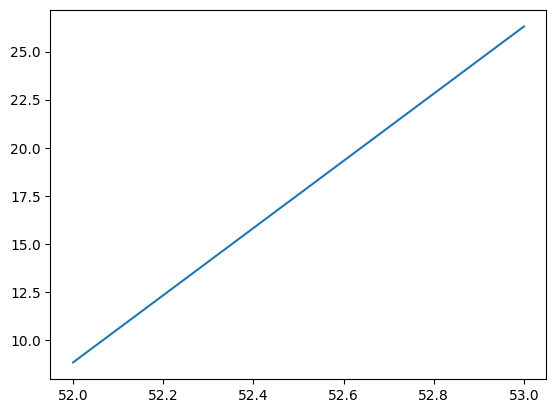

In [197]:
plt.plot(df_plot["roll_deg"][52:54])

In [198]:
52

gray_frame_last = gray_tensor[i]
gray_frame      = gray_tensor[i+1]

# relative rotation from frame i -> i+1
R_step = estimate_rotation_R(gray_frame_last, gray_frame, K)

In [199]:
R

array([[ 0.99972338,  0.02175708,  0.0089325 ],
       [-0.02136903,  0.99891189, -0.04145369],
       [-0.00982469,  0.04125134,  0.9991005 ]])

In [157]:
orientations
import pandas as pd

In [158]:
df = pd.DataFrame(orientations)

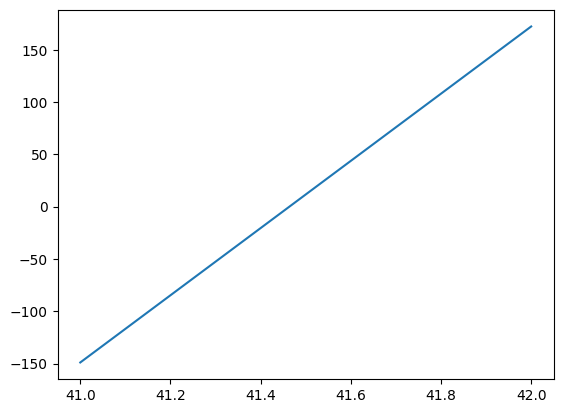

In [167]:
df = pd.DataFrame(orientations)
df_filtered = df[df["inliers"] >= 30]  # keep only frames with reliable orientation

# Plot
plt.figure(figsize=(10, 6))
plt.plot(df_filtered["frame"], df_filtered["yaw_deg"], label="Yaw")
plt.plot(df_filtered["frame"], df_filtered["pitch_deg"], label="Pitch")
plt.plot(df_filtered["frame"], df_filtered["roll_deg"], label="Roll")
plt.xlabel("Frame")
plt.ylabel("Degrees")
plt.title("Filtered Camera Orientation Over Time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
plt.imshow

In [44]:
target_color = np.array([0.87058824, 0.85490197, 0.39215687], dtype=np.float32)

# Compute a mask where each pixel exactly matches the target color
mask = np.all(video_tensor == target_color, axis=-1)  # shape: (N, H, W)

# Expand mask to shape (N, H, W, 1) for broadcasting
  # or 1e-3
tol = 1e-1
mask = np.all(np.abs(video_tensor - target_color) < tol, axis=-1)
mask = mask[..., np.newaxis]
filtered_video = video_tensor * mask# Zero out non-matching pixels


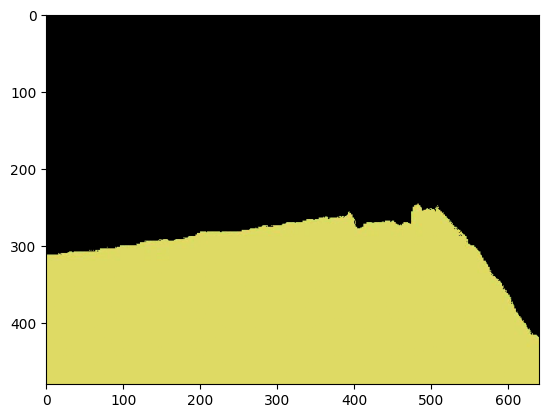

In [45]:
plt.imshow(filtered_video[100])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.3941176].


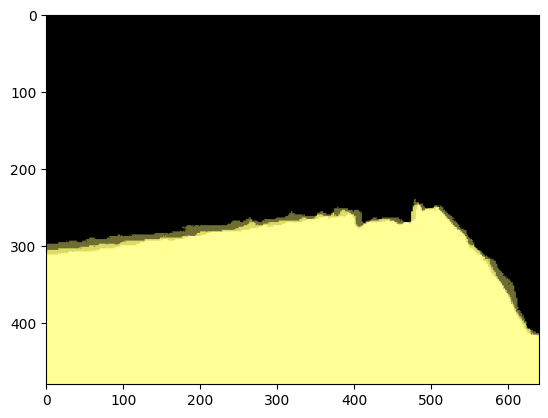

In [50]:
plt.imshow((filtered_video[100] + filtered_video[101] + filtered_video[101]) / 2)

In [51]:
import numpy as np

def geometric_average(tensor: np.ndarray, n: int, lambda_: float) -> np.ndarray:
    """
    Geometric (exponentially) weighted average over the last up to n frames in `tensor`.
    `tensor` is shaped (T, ...), ordered oldest -> newest. Returns a single frame (...).

    Weights ~ lambda_^k with k decreasing toward the newest frame, i.e. newest gets weight 1.
    For lambda_ = 0 -> newest only; lambda_ = 1 -> uniform over the window.
    """
    if tensor.ndim < 1 or tensor.shape[0] == 0:
        raise ValueError("`tensor` must have shape (T, ...) with T >= 1")
    if n <= 0:
        raise ValueError("`n` must be > 0")
    # clamp lambda_ to [0, 1]
    lambda_ = float(max(0.0, min(1.0, lambda_)))

    T = tensor.shape[0]
    m = min(int(n), T)
    window = tensor[-m:]

    # weights for [oldest ... newest] = [lambda_^(m-1), ..., lambda_^1, lambda_^0]
    exps = np.arange(m - 1, -1, -1, dtype=np.float64)
    w = np.power(lambda_, exps)
    w /= w.sum()

    # compute weighted average in float for precision
    work_dtype = np.float32 if tensor.dtype.kind != 'f' else tensor.dtype
    window_f = window.astype(work_dtype, copy=False)
    out = np.tensordot(w, window_f, axes=(0, 0))  # shape (...,)

    # cast back to input dtype if needed (round for integers)
    if tensor.dtype != out.dtype:
        if np.issubdtype(tensor.dtype, np.integer):
            out = np.rint(out).astype(tensor.dtype, copy=False)
        else:
            out = out.astype(tensor.dtype, copy=False)
    return out


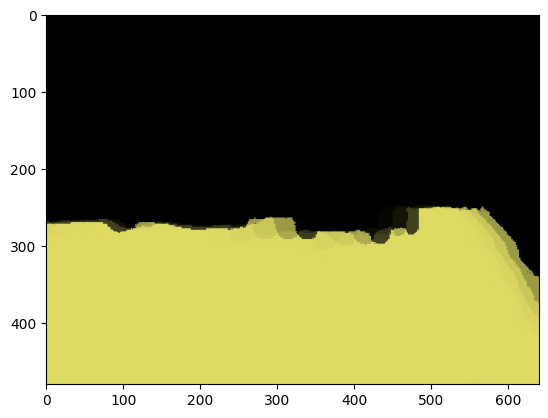

In [64]:
n = 30

plt.imshow(geometric_average(filtered_video[n:n+50], 5, 0.3))

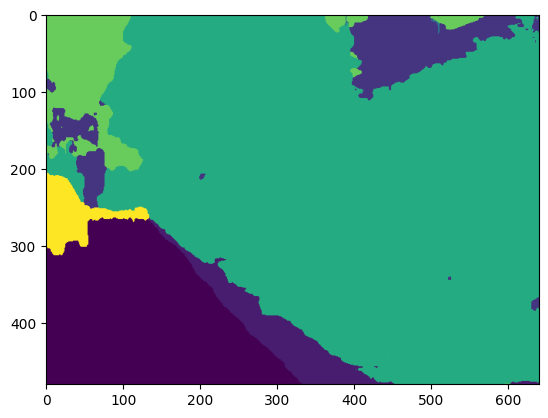

In [111]:
plt.imshow(segmened_video[80])

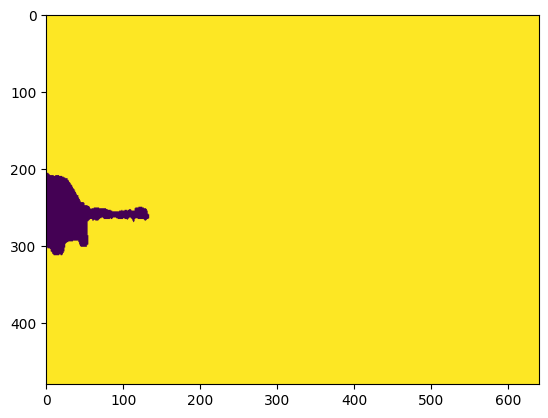

In [118]:
plt.imshow(np.not_equal(segmened_video[80], 13))

In [112]:
values, counts = np.unique(segmened_video[80], return_counts=True)

# Print results
for val, count in zip(values, counts):
    print(f"Class {val}: {count} pixels")

Class 0: 47381 pixels
Class 1: 10491 pixels
Class 2: 17511 pixels
Class 5: 77 pixels
Class 8: 209475 pixels
Class 9: 9 pixels
Class 10: 16796 pixels
Class 13: 5460 pixels


In [41]:
mask.shape

(300, 480, 640)

In [3]:
import random

In [206]:
total_balance 

4457619.4495829195

In [138]:
total_balance 

68502293.82850145

In [62]:
n = 0
for i in range(10000):
    n += biased_coin_flip(0.8)

In [63]:
n

8051

In [20]:
random.random() < 0.5

True